In [1]:
import helpers
import numpy as np
from scipy.ndimage import gaussian_filter
import nibabel as nib
from sklearn.preprocessing import MinMaxScaler
import skimage
import matplotlib.pyplot as plt

In [2]:
def create_circle_level_set(shape, center=None, radius=None):
    h, w = shape

    if center is None:
        center = (h // 2, w // 2)

    if radius is None:
        radius = min(h, w) // 4

    y, x = np.mgrid[:h, :w]

    return np.sqrt((x - center[1])**2 +
                   (y - center[0])**2) - radius


def gradient(phi):
    return np.gradient(phi)


def curvature(phi):
    phi_y, phi_x = gradient(phi)

    s = np.sqrt(phi_x**2 + phi_y**2 + 1e-10)

    nx = phi_x / s
    ny = phi_y / s

    nxx = np.gradient(nx, axis=1)
    nyy = np.gradient(ny, axis=0)

    return nxx + nyy


def dirac(phi, eps=1.5):
    return (eps / np.pi) / (eps**2 + phi**2)


def laplacian(img):
    gy, gx = np.gradient(img)
    return (
        np.gradient(gx, axis=1)
        + np.gradient(gy, axis=0)
    )


def drlse(
    image,
    iterations=500,
    timestep=1.0,
    mu=0.2,
    lambda_=5.0,
    alpha=-3.0,
    sigma=1.5,
):
    """
    Distance Regularized Level Set Evolution (DRLSE)

    image: grayscale ndarray [0,1]
    """

    image = image.astype(np.float64)

    # Smooth image
    smoothed = gaussian_filter(image, sigma)

    # Edge indicator
    Iy, Ix = np.gradient(smoothed)

    f = Ix**2 + Iy**2

    g = 1.0 / (1.0 + f)

    gy, gx = np.gradient(g)

    phi = create_circle_level_set(image.shape)

    for _ in range(iterations):

        phi_y, phi_x = np.gradient(phi)

        s = np.sqrt(phi_x**2 + phi_y**2 + 1e-10)

        nx = phi_x / s
        ny = phi_y / s

        curv = curvature(phi)

        # Distance regularization
        dist_reg = laplacian(phi) - curv

        # Edge attraction
        edge_term = dirac(phi) * (
            gx * nx +
            gy * ny +
            g * curv
        )

        # Balloon force
        area_term = dirac(phi) * g

        phi += timestep * (
            mu * dist_reg
            + lambda_ * edge_term
            + alpha * area_term
        )

    return phi, phi <= 0

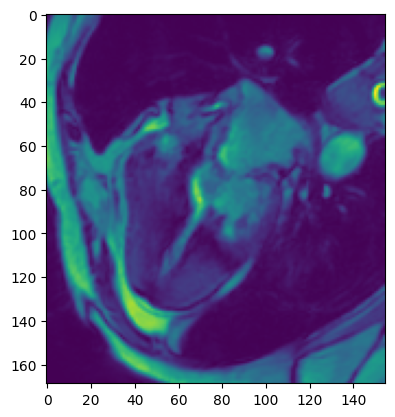

In [3]:
image_path = r"C:\\Users\\ayman.mohamed\\Personal\\Masters_Security\\Deep_Learning\\CINE_Cardiac_MRI_With_Deep_Learning\\CMR-MULTI\\CINE_MULTI\\4CH_TR\\image\\CINE_4CH_004.nii.gz"
np_img = nib.load(image_path).get_fdata()[:,:,0]


img_flat = np_img.reshape(-1, 1)
image_scaled = MinMaxScaler().fit_transform(img_flat)
image_scaled = image_scaled.reshape(np_img.shape)


plt.imshow(image_scaled)

In [4]:
phi, mask = drlse(
    image_scaled,
    iterations=800,
    timestep=0.5,
    mu=0.2,
    lambda_=5,
    alpha=-3
)

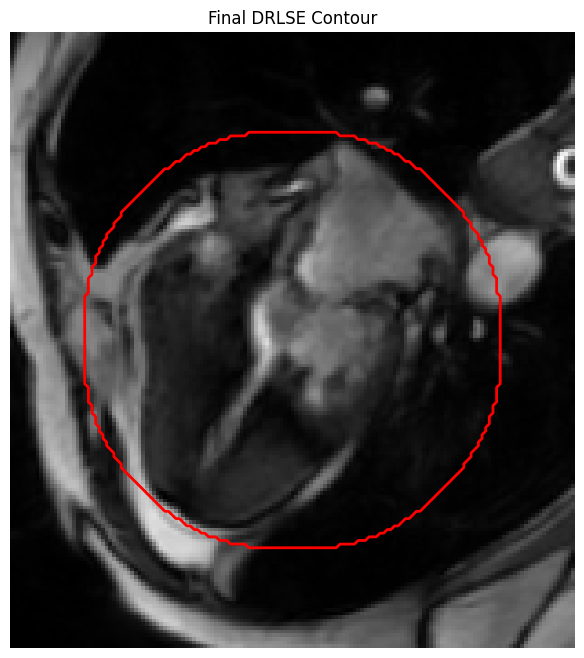

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(image_scaled, cmap='gray')

# Draw the zero level set (the active contour)
plt.contour(
    mask,
    levels=[0],
    colors='red',
    linewidths=2
)

plt.title("Final DRLSE Contour")
plt.axis('off')
plt.show()

In [10]:
import numpy as np
import time

from scipy.ndimage import binary_closing
from skimage.morphology import remove_small_objects, disk


def oracm(img, show=False):
    """
    Python translation of the provided MATLAB ORACM code.

    Parameters
    ----------
    img : ndarray (H,W)
        Grayscale image.
    show : bool
        Display intermediate iterations.

    Returns
    -------
    obj : ndarray
        Final contour representation (+1 object, -1 background)
    obj_pos : ndarray(bool)
        Object mask
    elapsed : float
        Runtime in seconds
    itr : int
        Number of iterations
    """

    img = img.astype(np.float64)

    rows, cols = img.shape

    # MATLAB:
    # phi = ones(row,col)
    # phi(k:row-k,k:col-k) = -1
    k = 10

    phi = np.ones((rows, cols), dtype=np.int8)

    phi[k:rows-k, k:cols-k] = -1

    obj = -phi

    obj_pos = obj >= 0
    obj_neg = ~obj_pos

    area1 = np.sum(obj_neg)
    area2 = np.sum(obj_pos)

    itr = 0

    if show:
        import matplotlib.pyplot as plt

        plt.figure()

    start = time.time()

    while abs(area2 - area1) > 0:

        c1 = img[obj_neg].mean()
        c2 = img[obj_pos].mean()

        nimg = img - (c1 + c2) / 2.0

        m = np.max(np.abs(nimg))

        if m > 0:
            obj = nimg / m
        else:
            break

        obj_pos = obj >= 0
        obj_neg = ~obj_pos

        # MATLAB:
        # obj = objPos - objNeg
        obj = obj_pos.astype(np.int8) - obj_neg.astype(np.int8)

        area1 = area2
        area2 = np.sum(obj_pos)

        itr += 1

        if show:
            plt.clf()
            plt.imshow(img, cmap="gray")

            plt.contour(
                obj,
                levels=[0],
                linewidths=2,
            )

            plt.title(
                f"ORACM Iteration {itr}, "
                f"Object Area = {area2}"
            )

            plt.pause(0.01)

    # MATLAB:
    # objPos=bwareaopen(objPos,20)
    obj_pos = remove_small_objects(
        obj_pos,
        min_size=20
    )

    # MATLAB:
    # objPos=imclose(objPos,strel('disk',3))
    obj_pos = binary_closing(
        obj_pos,
        structure=disk(3)
    )

    obj_neg = ~obj_pos

    obj = (
        obj_pos.astype(np.int8)
        - obj_neg.astype(np.int8)
    )

    elapsed = time.time() - start

    return obj, obj_pos, elapsed, itr

In [12]:
import matplotlib.pyplot as plt


def show_mask(image, mask, show_contour=True):
    """
    Display ORACM segmentation result.

    Parameters
    ----------
    image : ndarray
        Original grayscale image.
    mask : ndarray(bool)
        Binary segmentation mask returned by ORACM.
    show_contour : bool
        Draw contour boundary on top of image.
    """

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Binary mask
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")

    # Overlay
    axes[2].imshow(image, cmap="gray")

    axes[2].imshow(
        mask,
        cmap="Reds",
        alpha=0.35
    )

    if show_contour:
        axes[2].contour(
            mask.astype(float),
            levels=[0.5],
            colors="yellow",
            linewidths=2
        )

    axes[2].set_title("Mask Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

C:\Users\ayman.mohamed\AppData\Local\Temp\ipykernel_23936\39169222.py:106: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  obj_pos = remove_small_objects(


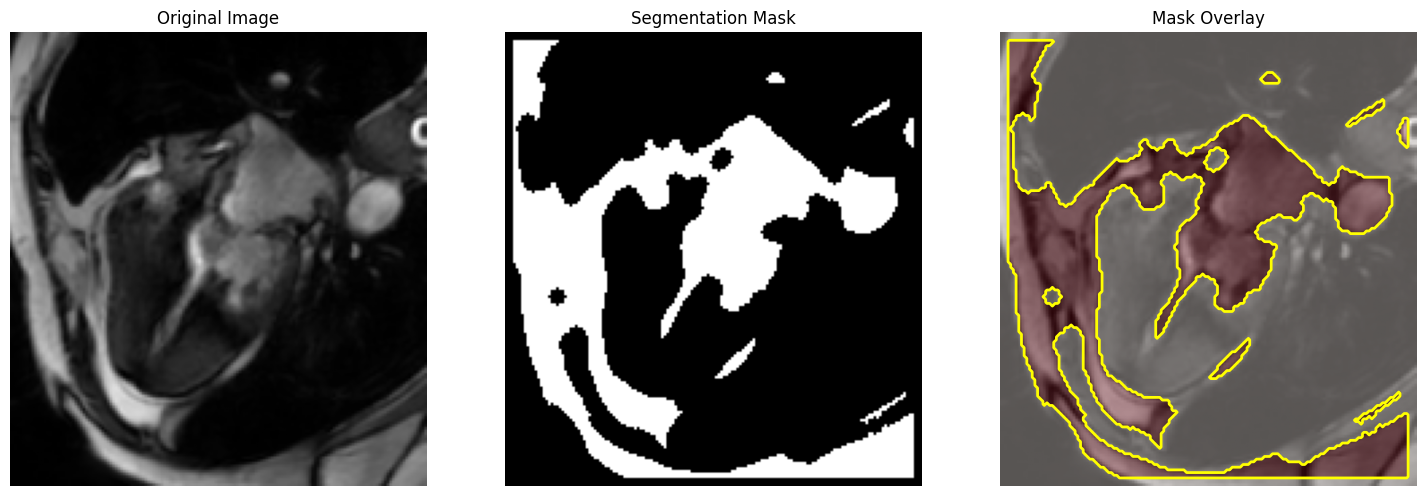

Iterations: 11
Runtime: 0.0071 s


In [15]:
obj, mask, runtime, iterations = oracm(image_scaled)

show_mask(image_scaled, mask)

print(f"Iterations: {iterations}")
print(f"Runtime: {runtime:.4f} s")

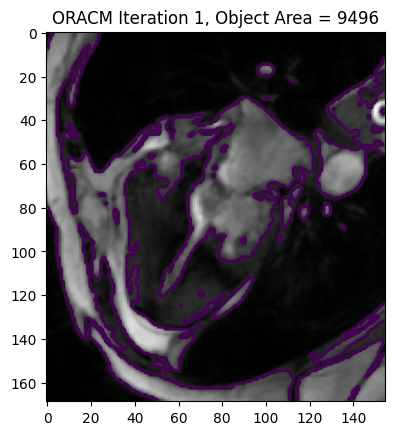

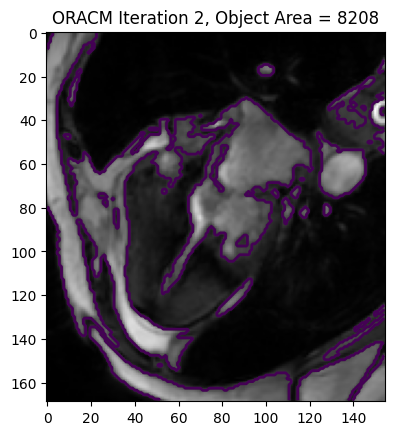

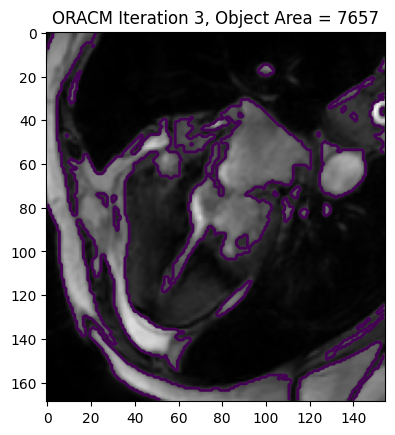

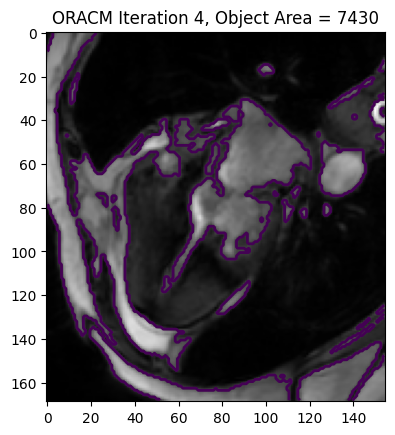

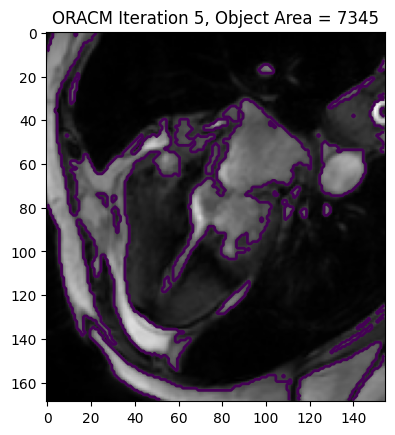

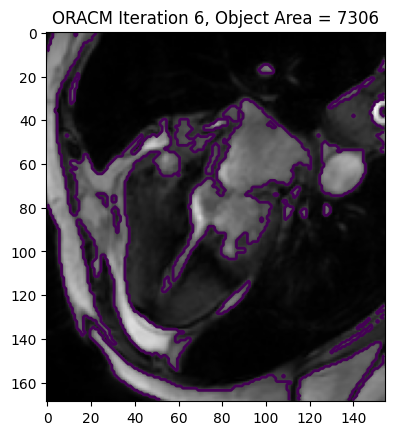

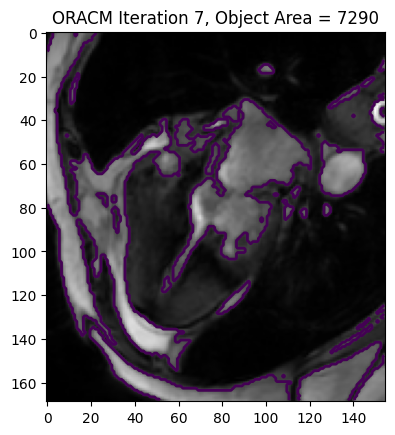

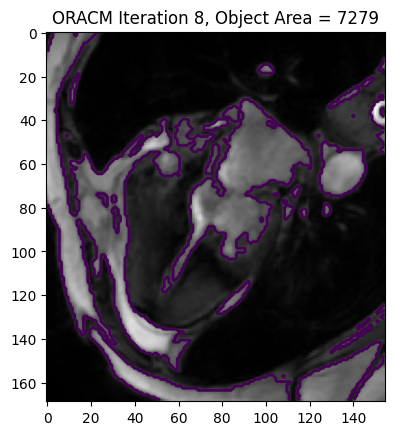

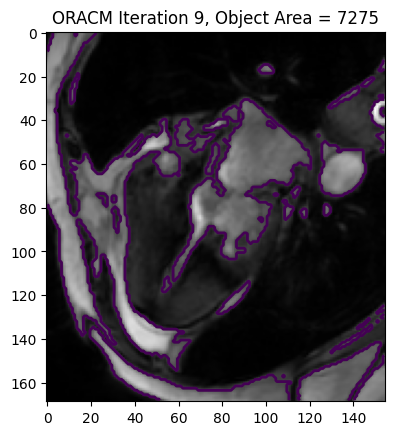

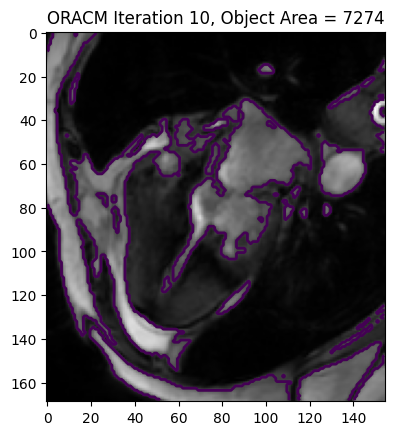

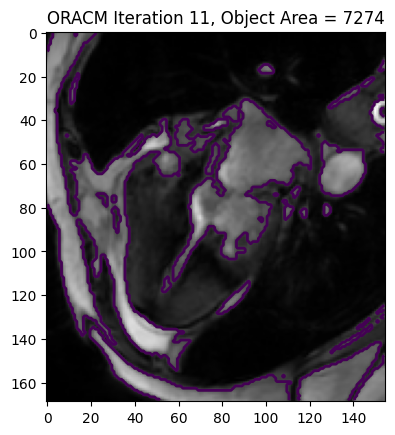

C:\Users\ayman.mohamed\AppData\Local\Temp\ipykernel_23936\39169222.py:106: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  obj_pos = remove_small_objects(


(array([[-1, -1, -1, ..., -1, -1, -1],
        [-1, -1, -1, ..., -1, -1, -1],
        [-1, -1, -1, ..., -1, -1, -1],
        ...,
        [-1, -1, -1, ..., -1, -1, -1],
        [-1, -1, -1, ..., -1, -1, -1],
        [-1, -1, -1, ..., -1, -1, -1]], shape=(169, 155), dtype=int8),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(169, 155)),
 2.2786221504211426,
 11)

In [11]:
oracm(image_scaled, show=True)